# Spurious correlations on SpuCoMNIST

The three steps in the task:

1. Train a LeNet with ERM.
2. Cluster the ERM outputs within each class.
3. Train a new LeNet with group-balanced sampling on the inferred groups.

I first work through seed 0 one step at a time. For clustering I use a separate one-epoch ERM model;
the 20-epoch ERM is only the baseline.

In [1]:
# Install before importing matplotlib: SpuCo calls cm.get_cmap, which matplotlib 3.11 removed.
%pip install -q "spuco==2.0.3" "matplotlib<3.11"


Note: you may need to restart the kernel to use updated packages.


In [2]:
import time, json, statistics as st
from importlib.metadata import version
import numpy as np, torch, matplotlib, matplotlib.cm, matplotlib.pyplot as plt
import torch.utils.data as tud

# Record the package versions these outputs came from.
for pkg in ("spuco", "torch", "torchvision", "numpy", "scikit-learn", "matplotlib"):
    print(f"  {pkg:14} {version(pkg)}")
assert version("spuco") == "2.0.3", "these outputs were produced with spuco 2.0.3"
assert hasattr(matplotlib.cm, "get_cmap"), "matplotlib too new: pin below 3.11"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

# Hide the progress bars so the numbers are easier to read.
import tqdm, functools, warnings
tqdm.tqdm.__init__ = functools.partialmethod(tqdm.tqdm.__init__, disable=True)
# tqdm also warns once about ipywidgets, which is noise here.
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

# Evaluation was much slower with worker processes in this notebook environment. The evaluator does
# not expose DataLoader settings, so I set them here. pin_memory=False only avoids a warning, since
# PyTorch already disables it on this backend. The flag keeps a rerun from patching twice.
if not getattr(tud.DataLoader, "_workers_off", False):
    _real_dataloader = tud.DataLoader
    def _dataloader(*a, **kw):
        kw["num_workers"] = 0
        kw["pin_memory"] = False
        return _real_dataloader(*a, **kw)
    _dataloader._workers_off = True
    tud.DataLoader = _dataloader

  spuco          2.0.3
  torch          2.13.0
  torchvision    0.28.0
  numpy          2.5.2
  scikit-learn   1.9.0
  matplotlib     3.10.9
device: cpu


In [3]:
from spuco.datasets import SpuCoMNIST, SpuriousFeatureDifficulty
from spuco.utils import set_seed

# Settings from the SpuCo quickstarts. small_cluster_max is only used in the checks, not training.
CFG = dict(
    classes            = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]],  # 5 classes of 2 digits
    difficulty         = SpuriousFeatureDifficulty.MAGNITUDE_LARGE,
    strength           = 0.995,   # 0.0 is rejected for the train split; 0.995
                                  # matches the quickstart
    batch_size         = 64,      # must be at least the number of groups, 25
    lr                 = 1e-2,
    weight_decay       = 1e-4,
    momentum           = 0.9,
    infer_epochs       = 1,       # the quickstart uses one
    epochs             = 20,      # ERM baseline and both retrains
    seeds              = [0, 1, 2, 3, 4],
    small_cluster_max  = 1000,    # reporting cutoff only, for the size gap
                                  # printed below between 51 and 8965
    root               = "data/mnist",
)
for k, v in CFG.items():
    print(f"{k:18} {v}")

classes            [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
difficulty         SpuriousFeatureDifficulty.MAGNITUDE_LARGE
strength           0.995
batch_size         64
lr                 0.01
weight_decay       0.0001
momentum           0.9
infer_epochs       1
epochs             20
seeds              [0, 1, 2, 3, 4]
small_cluster_max  1000
root               data/mnist


In [4]:
# Set the seed first because SpuCoMNIST uses it when assigning the minority examples.
set_seed(CFG["seeds"][0])

def build(split, strength=None):
    ds = SpuCoMNIST(root=CFG["root"], spurious_feature_difficulty=CFG["difficulty"],
                    classes=CFG["classes"], split=split,
                    **({"spurious_correlation_strength": strength} if strength is not None else {}))
    ds.initialize()
    return ds

trainset = build("train", CFG["strength"])
testset  = build("test")

sizes = {k: len(v) for k, v in trainset.group_partition.items()}
# A group is minority when its background is not its own class's.
minority_total = sum(n for (c, s), n in sizes.items() if s != c)
print(f"train {len(trainset)}, test {len(testset)}, groups {len(sizes)}")
print("group (class, colour) -> size, class 0:",
      {k: v for k, v in sizes.items() if k[0] == 0})
print(f"minority examples in the whole training set: {minority_total}")

train 48004, test 10000, groups 25
group (class, colour) -> size, class 0: {(0, 0): 10082, (0, 3): 15, (0, 2): 7, (0, 4): 14, (0, 1): 15}
minority examples in the whole training set: 243


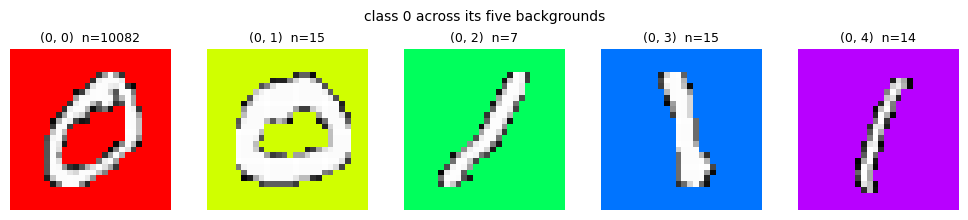

In [5]:
# Class 0 under its five background colours. It contains digits 0 and 1, so the digit varies too.
fig, axes = plt.subplots(1, 5, figsize=(10, 2.2))
for ax, colour in zip(axes, range(5)):
    idx = trainset.group_partition[(0, colour)][0]
    ax.imshow(trainset[idx][0].permute(1, 2, 0).numpy())
    ax.set_title(f"(0, {colour})  n={sizes[(0, colour)]}", fontsize=9)
    ax.axis("off")
plt.suptitle("class 0 across its five backgrounds", fontsize=10)
plt.tight_layout(); plt.show()

In training, each class has its matching background colour in 99.5% of the examples. The test set
balances the colours, so colour gives almost no information about the label.

I started from the official [SpuCoMNIST clustering
quickstart](https://github.com/BigML-CS-UCLA/SpuCo/blob/master/quickstart/spuco_mnist/spuco_mnist_cluster.ipynb).
It uses one epoch of ERM, class-wise k-means with k=2 on the logits, batch size 64, and a fresh
model with `GroupBalanceBatchERM`. The 20-epoch SGD settings come from the [group-balance
quickstart](https://github.com/BigML-CS-UCLA/SpuCo/blob/master/quickstart/spuco_mnist/spuco_mnist_group_balance.py),
whose defaults are 20 epochs, learning rate 1e-2, weight decay 1e-4 and momentum 0.9. Beyond that
pipeline this notebook adds an ERM baseline, five seeds on one fixed dataset, checks on cluster
recovery, on the evaluation metric and on the sampler, and a true-group reference.

The [full George
quickstart](https://github.com/BigML-CS-UCLA/SpuCo/blob/master/quickstart/spuco_mnist/spuco_mnist_george.py)
is different: it clusters penultimate-layer features and trains with GroupDRO.

In [6]:
from spuco.models import model_factory
from spuco.utils import Trainer
from spuco.group_inference import Cluster, ClusterAlg
from spuco.robust_train import GroupBalanceBatchERM
from spuco.evaluate import Evaluator
from torch.optim import SGD

def new_model():
    return model_factory("lenet", trainset[0][0].shape, trainset.num_classes).to(DEVICE)

def optim(m):
    return SGD(m.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"],
               momentum=CFG["momentum"], nesterov=True)

def train_plain(model, epochs):
    """Train a model with standard ERM. Returns the Trainer, since step 2 needs its outputs."""
    tr = Trainer(trainset=trainset, model=model, batch_size=CFG["batch_size"],
                 optimizer=optim(model), device=DEVICE, verbose=False)
    tr.train(num_epochs=epochs)
    return tr

def train_group_balanced(model, partition, epochs):
    """Train a model with group-balanced sampling. Returns the trainer too, since its sampler
    still holds the indices the last epoch used."""
    gb = GroupBalanceBatchERM(model=model, num_epochs=epochs, trainset=trainset,
                              group_partition=partition, batch_size=CFG["batch_size"],
                              optimizer=optim(model), device=DEVICE, verbose=False)
    gb.train()
    return model, gb

def evaluate(model):
    ev = Evaluator(testset=testset, group_partition=testset.group_partition,
                   group_weights=trainset.group_weights, batch_size=CFG["batch_size"],
                   model=model, device=DEVICE, verbose=False)
    ev.evaluate()
    return ev

In [7]:
# ERM baseline. I use 20 epochs here and for both group-balanced runs.
# The clustering step uses a separate one-epoch model.
set_seed(CFG["seeds"][0])
t0 = time.time()
erm_model = new_model()
train_plain(erm_model, CFG["epochs"])
erm_secs = time.time() - t0

ev = evaluate(erm_model)
# average_accuracy is weighted by the training group sizes, so I also report the plain mean over
# the 25 test groups.
mean_over_groups = sum(ev.accuracies.values()) / len(ev.accuracies)
print(f"ERM: worst group {ev.worst_group_accuracy[1]:.2f}%"
      f"   train-weighted average {ev.average_accuracy:.2f}%"
      f"   mean over the 25 groups {mean_over_groups:.2f}%   ({erm_secs:.0f}s)")
print("\nper-group accuracy in percent, rows are classes, columns are backgrounds.")
print("        " + "".join(f"{b:>8}" for b in range(5)))
for c in range(5):
    print(f"class {c} " + "".join(f"{ev.accuracies[(c, b)]:8.2f}" for b in range(5)))

ERM: worst group 0.00%   train-weighted average 99.56%   mean over the 25 groups 29.30%   (188s)

per-group accuracy in percent, rows are classes, columns are backgrounds.
               0       1       2       3       4
class 0   100.00    0.00    0.00    6.15   83.22
class 1    26.16  100.00    0.00    7.35    7.84
class 2     0.00    0.00  100.00    9.87    0.00
class 3     0.75    0.00    0.00  100.00   41.31
class 4    42.32    0.00    0.00    7.58  100.00


In [8]:
# Train a separate ERM model for one epoch and cluster its logits.
set_seed(CFG["seeds"][0])
infer_trainer = train_plain(new_model(), CFG["infer_epochs"])
# features=True would use the penultimate layer. I fix k=2 instead of letting GeorgeInference choose it.
Z = infer_trainer.get_trainset_outputs()

partition = Cluster(Z=Z, class_labels=trainset.labels, cluster_alg=ClusterAlg.KMEANS,
                    num_clusters=2, device=DEVICE, verbose=False).infer_groups()

print(f"{len(partition)} inferred groups")
print("sizes:", sorted(len(v) for v in partition.values()))

10 inferred groups
sizes: [25, 46, 49, 49, 51, 8965, 9416, 9623, 9698, 10082]


In [9]:
# Compare each small cluster with the true minority examples.
# Inferred keys are (class, cluster); true keys are (class, colour).
true_minority = {i for (c, s), idx in trainset.group_partition.items()
                 if s != c for i in idx}

print(f"{'inferred group':>16}   {'n':>6}   {'% minority':>10}   {'% of all minority':>18}")
for k in sorted(partition, key=lambda k: len(partition[k])):
    got = set(partition[k]) & true_minority
    if len(partition[k]) < CFG["small_cluster_max"]:
        print(f"{str(k):>16}   {len(partition[k]):6d}   {100*len(got)/len(partition[k]):10.1f}"
              f"   {100*len(got)/len(true_minority):18.1f}")
small_keys = [k for k, v in partition.items() if len(v) < CFG["small_cluster_max"]]
recovered  = sum(len(set(partition[k]) & true_minority) for k in small_keys)
held       = sum(len(partition[k]) for k in small_keys)
print(f"\n{len({k[0] for k in small_keys})} of the 5 classes produced a small cluster")
print(f"those clusters hold {recovered} of the {len(true_minority)} minority examples, "
      f"so recall {100*recovered/len(true_minority):.1f}%, "
      f"and {recovered} of the {held} examples in them are minority, "
      f"so precision {100*recovered/held:.1f}%")

  inferred group        n   % minority    % of all minority
          (4, 1)       25        100.0                 10.3
          (2, 1)       46        100.0                 18.9
          (1, 1)       49        100.0                 20.2
          (3, 1)       49        100.0                 20.2
          (0, 1)       51        100.0                 21.0

5 of the 5 classes produced a small cluster
those clusters hold 220 of the 243 minority examples, so recall 90.5%, and 220 of the 220 examples in them are minority, so precision 100.0%


In [10]:
# Train a fresh model with group-balanced sampling on the inferred groups.
set_seed(CFG["seeds"][0])
t0 = time.time()
gb_model, gb = train_group_balanced(new_model(), partition, CFG["epochs"])
gb_secs = time.time() - t0

ev_gb = evaluate(gb_model)
print(f"group balanced on inferred groups: worst group {ev_gb.worst_group_accuracy[1]:.2f}%"
      f"   train-weighted average {ev_gb.average_accuracy:.2f}%   ({gb_secs:.0f}s)")
print(f"ERM was:                           worst group {ev.worst_group_accuracy[1]:.2f}%"
      f"   train-weighted average {ev.average_accuracy:.2f}%")

group balanced on inferred groups: worst group 30.75%   train-weighted average 99.75%   (190s)
ERM was:                           worst group 0.00%   train-weighted average 99.56%


## Two checks

`Evaluator.worst_group_accuracy` returns a `(group, value)` pair, and its average is weighted by the
training group sizes. I recompute the worst group and the plain mean over groups to be sure I am
comparing the numbers I mean to compare.

The task asks for groups balanced inside each batch. SpuCo balances them in expectation over the
epoch instead, so I look at the sampler indices the last epoch actually used.

In [11]:
# Check worst-group accuracy by hand. SpuCo returns a (group, value) pair.
@torch.no_grad()
def worst_group_by_hand(model, ds):
    model.eval()
    correct = {}
    loader = tud.DataLoader(ds, batch_size=256, shuffle=False)
    preds = torch.cat([model(x.to(DEVICE)).argmax(1).cpu() for x, _ in loader])
    labels = torch.tensor(ds.labels)
    for g, idx in sorted(ds.group_partition.items()):   # sort so ties match SpuCo's evaluator
        i = torch.tensor(idx)
        correct[g] = 100.0 * (preds[i] == labels[i]).float().mean().item()
    worst = min(correct, key=correct.get)
    return worst, correct[worst], float(np.mean(list(correct.values())))

g, w, a = worst_group_by_hand(gb_model, testset)
print(f"by hand:   worst group {w:.2f}% at {g}   mean over groups {a:.2f}%")
print(f"Evaluator: worst group {ev_gb.worst_group_accuracy[1]:.2f}% "
      f"at {ev_gb.worst_group_accuracy[0]}   train-weighted average "
      f"{ev_gb.average_accuracy:.2f}%")

by hand:   worst group 30.75% at (2, 4)   mean over groups 68.84%
Evaluator: worst group 30.75% at (2, 4)   train-weighted average 99.75%


In [12]:
# Inspect the indices the last epoch sampled. The sampler is unshuffled, so the batches are
# consecutive chunks of that list.
from collections import Counter
epoch = list(gb.trainer.sampler.indices)
group_of = {i: k for k, idx in partition.items() for i in idx}
sizes_p = {k: len(v) for k, v in partition.items()}
small = {k for k in partition if sizes_p[k] < CFG["small_cluster_max"]}
B = CFG["batch_size"]
# The epoch does not divide evenly, so the last batch is short and is reported apart.
cut = len(epoch) - len(epoch) % B
full_batches = [epoch[i:i + B] for i in range(0, cut, B)]
tail = epoch[cut:]
def share(b):
    return 100 * sum(group_of[i] in small for i in b) / len(b)
per_batch = [share(b) for b in full_batches]

print(f"small clusters are {100*sum(sizes_p[k] for k in small)/len(trainset):.2f}% of the training set")
print(f"the sampler weights all {len(sizes_p)} inferred groups equally, so these {len(small)} should get "
      f"{100*len(small)/len(sizes_p):.0f}% of the epoch, and they got "
      f"{100*sum(group_of[i] in small for i in epoch)/len(epoch):.2f}%")
print(f"across the {len(full_batches)} full batches of {B}: mean {st.mean(per_batch):.1f}%, "
      f"range {min(per_batch):.1f}% to {max(per_batch):.1f}%")
if tail:
    print(f"and one last batch of {len(tail)}, at {share(tail):.1f}%, which the loader keeps")

# SpuCo balances the groups in expectation over the epoch, not exactly inside each batch.
counts = Counter(epoch)
smallest = min(sizes_p, key=lambda k: sizes_p[k])
draws = [counts[i] for i in partition[smallest]]
print(f"an example in the smallest cluster came up {st.mean(draws):.0f} times on average in that "
      f"one epoch; the run trains for {CFG['epochs']}")

small clusters are 0.46% of the training set
the sampler weights all 10 inferred groups equally, so these 5 should get 50% of the epoch, and they got 49.65%
across the 750 full batches of 64: mean 49.6%, range 28.1% to 71.9%
and one last batch of 4, at 75.0%, which the loader keeps
an example in the smallest cluster came up 190 times on average in that one epoch; the run trains for 20


In [13]:
# Reference only: use the true groups to see how the same trainer behaves without group-inference error.
set_seed(CFG["seeds"][0])
t0 = time.time()
oracle_model, _ = train_group_balanced(new_model(), trainset.group_partition, CFG["epochs"])
oracle_secs = time.time() - t0
ev_or = evaluate(oracle_model)
print(f"group balanced on TRUE groups: worst group {ev_or.worst_group_accuracy[1]:.2f}%"
      f"   train-weighted average {ev_or.average_accuracy:.2f}%   ({oracle_secs:.0f}s)")

group balanced on TRUE groups: worst group 40.37%   train-weighted average 99.71%   (194s)


In [14]:
# One seed can be misleading for worst-group accuracy, so repeat all three runs over five seeds.
# The dataset stays fixed, so the minority examples are the same every time.
# Seed 0 should match the earlier cells.
def worst_and_mean(model):
    """Worst group, and the plain mean over the 25 test groups. The second one is not
    Evaluator.average_accuracy, which is weighted by training frequency."""
    e = evaluate(model)
    return e.worst_group_accuracy[1], sum(e.accuracies.values()) / len(e.accuracies)

rows = []
for seed in CFG["seeds"]:
    t0 = time.time()
    # Reset before each model so all four models for a seed use the same initialization seed.
    set_seed(seed); m_erm = new_model(); train_plain(m_erm, CFG["epochs"])
    set_seed(seed); Zs = train_plain(new_model(), CFG["infer_epochs"]).get_trainset_outputs()
    part = Cluster(Z=Zs, class_labels=trainset.labels, cluster_alg=ClusterAlg.KMEANS,
                   num_clusters=2, device=DEVICE, verbose=False).infer_groups()
    small_k = [k for k, v in part.items() if len(v) < CFG["small_cluster_max"]]
    got  = sum(len(set(part[k]) & true_minority) for k in small_k)
    held = sum(len(part[k]) for k in small_k)
    set_seed(seed); m_gb, _ = train_group_balanced(new_model(), part, CFG["epochs"])
    set_seed(seed); m_or, _ = train_group_balanced(new_model(), trainset.group_partition, CFG["epochs"])
    erm_w, erm_m = worst_and_mean(m_erm)
    inf_w, inf_m = worst_and_mean(m_gb)
    tru_w, tru_m = worst_and_mean(m_or)
    r = dict(seed=seed,
             minority_recall=100 * got / len(true_minority),
             minority_precision=100 * got / held,
             classes_with_small_cluster=len({k[0] for k in small_k}),
             erm=erm_w, inferred=inf_w, true=tru_w,
             erm_mean=erm_m, inferred_mean=inf_m, true_mean=tru_m,
             secs=round(time.time() - t0))
    rows.append(r)
    print(f"seed {seed}: worst group   ERM {erm_w:5.2f}%   inferred {inf_w:5.2f}%"
          f"   true {tru_w:5.2f}%   ({r['secs']}s)")

print("\nWorst-group accuracy on the balanced test set for the three arms, and the")
print("clustering's recall and precision on the minority examples. All figures are percentages.")
print(f"{'':>10}{'ERM':>9}{'inferred':>11}{'true':>9}{'recall':>9}{'precision':>11}{'classes':>9}")
for r in rows:
    print(f"seed {r['seed']:<5}{r['erm']:9.2f}{r['inferred']:11.2f}{r['true']:9.2f}"
          f"{r['minority_recall']:9.1f}{r['minority_precision']:11.1f}"
          f"{r['classes_with_small_cluster']:9d}")
print(f"{'mean':<10}{st.mean([r['erm'] for r in rows]):9.2f}"
      f"{st.mean([r['inferred'] for r in rows]):11.2f}"
      f"{st.mean([r['true'] for r in rows]):9.2f}")
print(f"{'spread':<10}{max(r['erm'] for r in rows)-min(r['erm'] for r in rows):9.2f}"
      f"{max(r['inferred'] for r in rows)-min(r['inferred'] for r in rows):11.2f}"
      f"{max(r['true'] for r in rows)-min(r['true'] for r in rows):9.2f}")
print(f"mean over the 25 test groups, averaged over seeds:"
      f"   ERM {st.mean([r['erm_mean'] for r in rows]):.2f}%"
      f"   inferred {st.mean([r['inferred_mean'] for r in rows]):.2f}%"
      f"   true groups {st.mean([r['true_mean'] for r in rows]):.2f}%")
print(f"\nseed loop {sum(r['secs'] for r in rows)}s on {DEVICE}; "
      f"the single-seed cells above add roughly {erm_secs+gb_secs+oracle_secs:.0f}s more")
with open("results.json", "w") as f:
    json.dump({"config": {k: str(v) for k, v in CFG.items()}, "results": rows}, f, indent=2)

seed 0: worst group   ERM  0.00%   inferred 30.75%   true 40.37%   (602s)


seed 1: worst group   ERM  0.00%   inferred 35.26%   true 38.77%   (607s)


seed 2: worst group   ERM  0.00%   inferred 26.47%   true 35.77%   (605s)


seed 3: worst group   ERM  0.00%   inferred 13.90%   true 34.76%   (599s)


seed 4: worst group   ERM  0.00%   inferred 27.27%   true 29.14%   (597s)

Worst-group accuracy on the balanced test set for the three arms, and the
clustering's recall and precision on the minority examples. All figures are percentages.
                ERM   inferred     true   recall  precision  classes
seed 0         0.00      30.75    40.37     90.5      100.0        5
seed 1         0.00      35.26    38.77     93.0      100.0        5
seed 2         0.00      26.47    35.77    100.0      100.0        5
seed 3         0.00      13.90    34.76     91.4      100.0        5
seed 4         0.00      27.27    29.14    100.0      100.0        5
mean           0.00      26.73    35.76
spread         0.00      21.36    11.23
mean over the 25 test groups, averaged over seeds:   ERM 30.31%   inferred 70.49%   true groups 77.83%

seed loop 3010s on cpu; the single-seed cells above add roughly 571s more


## Results

ERM gets 0.00% worst-group accuracy for every seed, although some test groups are much easier than
others. For seed 0, one group is at 83%.

Training with the inferred groups raises worst-group accuracy to between 13.90% and 35.26%. Training
with the true groups gives 29.14% to 40.37%. Averaged over the 5 seeds, mean accuracy over the 25
test groups is 30.31% for ERM, 70.49% with inferred groups, and 77.83% with true groups.

In all 5 runs, the small clusters contain only minority examples and recover 90.5% to 100.0% of
them. The result still changes a lot across seeds, including when I use the true groups.

I only tried one difficulty, one correlation strength, and two clusters per class, with no tuning.
The true-group runs also change across seeds, so I cannot tell how much of the gap between the
inferred and the true groups comes from clustering error and how much is training randomness.